In [1]:
import os

# Set working directory to project root always
# Works regardless of where the notebook is saved
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.abspath(os.path.join(notebook_dir, '..'))
os.chdir(project_root)

print("Working directory set to:", os.getcwd())

Working directory set to: c:\Users\DELL\OneDrive\Documents\SRM\Churn_Analysis


In [2]:
import numpy as np
import pandas as pd

from xgboost import XGBClassifier

X_train = np.load(
    'outputs/X_train_banking.npy'
)

X_test = np.load(
    'outputs/X_test_banking.npy'
)

y_train = np.load(
    'outputs/y_train_banking.npy'
)

y_test = np.load(
    'outputs/y_test_banking.npy'
)

print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

Train Shape: (12740, 10)
Test Shape : (2000, 10)


In [3]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(
    X_train,
    y_train
)

print(
    "Banking XGBoost trained successfully."
)

Banking XGBoost trained successfully.


In [4]:
y_pred = xgb_model.predict(
    X_test
)

y_proba = xgb_model.predict_proba(
    X_test
)[:,1]

In [5]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

acc = accuracy_score(
    y_test,
    y_pred
)

prec = precision_score(
    y_test,
    y_pred
)

rec = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

auc = roc_auc_score(
    y_test,
    y_proba
)

print("="*50)
print("Banking - XGBoost")
print("="*50)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

print("="*50)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            'Retained',
            'Exited'
        ]
    )
)

Banking - XGBoost
Accuracy  : 0.8470
Precision : 0.6305
Recall    : 0.5995
F1 Score  : 0.6146
ROC-AUC   : 0.8589
              precision    recall  f1-score   support

    Retained       0.90      0.91      0.90      1593
      Exited       0.63      0.60      0.61       407

    accuracy                           0.85      2000
   macro avg       0.76      0.75      0.76      2000
weighted avg       0.84      0.85      0.85      2000



<Figure size 600x500 with 0 Axes>

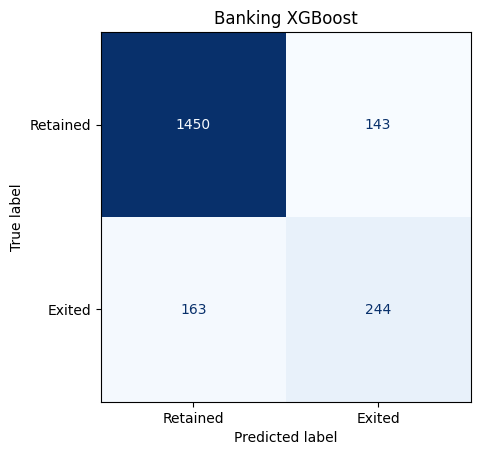

In [6]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        'Retained',
        'Exited'
    ]
)

plt.figure(figsize=(6,5))

disp.plot(
    cmap='Blues',
    colorbar=False
)

plt.title(
    'Banking XGBoost'
)

plt.show()

<Figure size 600x500 with 0 Axes>

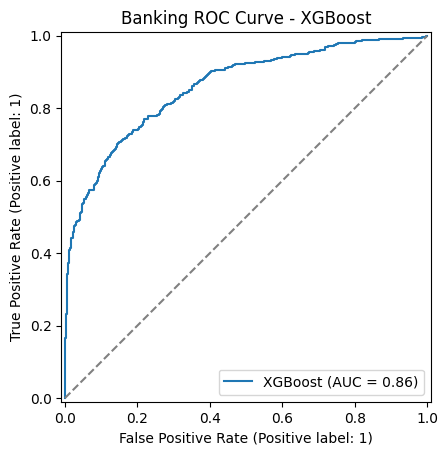

In [7]:
from sklearn.metrics import (
    RocCurveDisplay
)

plt.figure(figsize=(6,5))

RocCurveDisplay.from_predictions(
    y_test,
    y_proba,
    name='XGBoost'
)

plt.plot(
    [0,1],
    [0,1],
    '--',
    color='gray'
)

plt.title(
    'Banking ROC Curve - XGBoost'
)

plt.show()

In [8]:
feature_names = pd.read_csv(
    'outputs/banking_feature_names.csv'
).squeeze()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(
    importance_df.head(15)
)

           Feature  Importance
8   IsActiveMember    0.256638
6    NumOfProducts    0.244906
3              Age    0.133991
4           Tenure    0.088932
2           Gender    0.079275
1        Geography    0.068049
5          Balance    0.048519
7        HasCrCard    0.034089
9  EstimatedSalary    0.023153
0      CreditScore    0.022447


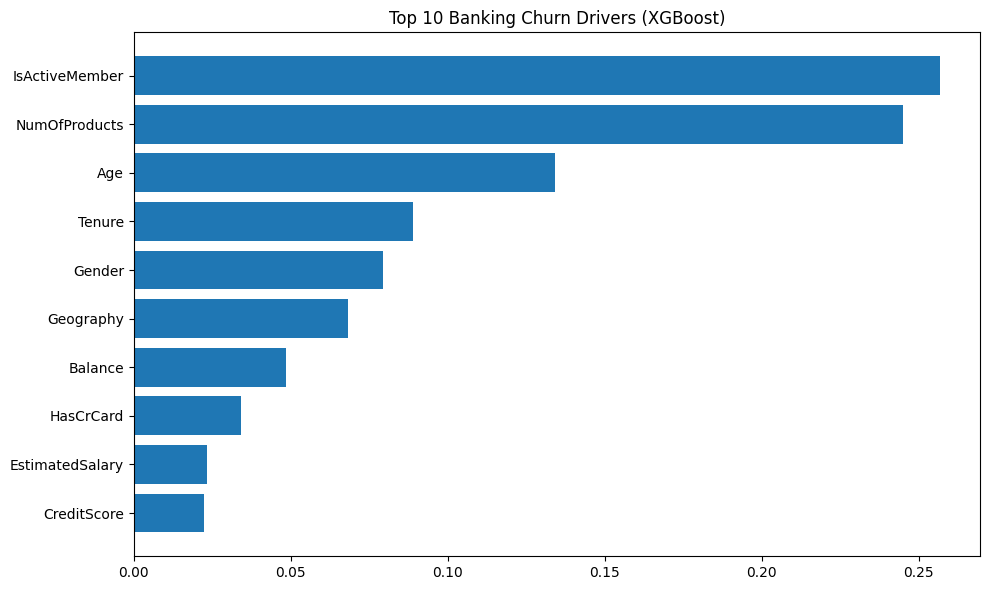

In [9]:
plt.figure(figsize=(10,6))

plt.barh(
    importance_df['Feature'][:10],
    importance_df['Importance'][:10]
)

plt.title(
    'Top 10 Banking Churn Drivers (XGBoost)'
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [10]:
import joblib

joblib.dump(
    xgb_model,
    'outputs/xgb_model_banking.pkl'
)

print(
    "XGBoost model saved successfully."
)

XGBoost model saved successfully.


In [11]:
import os

os.makedirs(
    'outputs/results',
    exist_ok=True
)

results = {
    'Sector'    : 'Banking',
    'Model'     : 'XGBoost',
    'Accuracy'  : round(acc,4),
    'Precision' : round(prec,4),
    'Recall'    : round(rec,4),
    'F1'        : round(f1,4),
    'ROC_AUC'   : round(auc,4)
}

results_df = pd.DataFrame(
    [results]
)

results_df.to_csv(
    'outputs/results/banking_xgb_results.csv',
    index=False
)

print(results_df)

    Sector    Model  Accuracy  Precision  Recall      F1  ROC_AUC
0  Banking  XGBoost     0.847     0.6305  0.5995  0.6146   0.8589


In [12]:
predictions_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,
    'Probability': y_proba
})

predictions_df.to_csv(
    'outputs/results/banking_xgb_predictions.csv',
    index=False
)

print(
    "Predictions saved successfully."
)

Predictions saved successfully.
